Using Device: cuda
Training Samples: 48000
Validation Samples: 12000
Testing Samples: 10000

Training New Experiment
Optimizer: Adam
Learning Rate: 0.001
Batch Size: 64

Epoch [1/5] | Train Loss: 0.1659 | Train Acc: 94.85% | Val Loss: 0.0563 | Val Acc: 98.25%
Epoch [2/5] | Train Loss: 0.0713 | Train Acc: 97.74% | Val Loss: 0.0584 | Val Acc: 98.00%
Epoch [3/5] | Train Loss: 0.0576 | Train Acc: 98.19% | Val Loss: 0.0393 | Val Acc: 98.72%
Epoch [4/5] | Train Loss: 0.0465 | Train Acc: 98.48% | Val Loss: 0.0407 | Val Acc: 98.68%
Epoch [5/5] | Train Loss: 0.0422 | Train Acc: 98.67% | Val Loss: 0.0355 | Val Acc: 98.90%

Testing Results
Test Accuracy: 99.09% | Test Loss: 0.0256


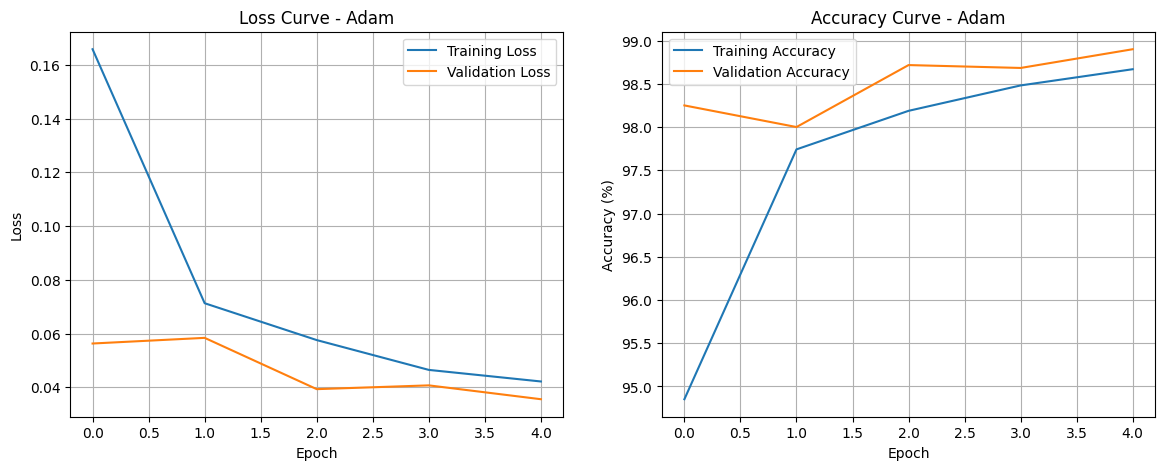


Training New Experiment
Optimizer: SGD
Learning Rate: 0.01
Batch Size: 128

Epoch [1/5] | Train Loss: 0.2303 | Train Acc: 92.67% | Val Loss: 0.0653 | Val Acc: 98.00%
Epoch [2/5] | Train Loss: 0.0760 | Train Acc: 97.57% | Val Loss: 0.0449 | Val Acc: 98.56%
Epoch [3/5] | Train Loss: 0.0584 | Train Acc: 98.20% | Val Loss: 0.0412 | Val Acc: 98.68%
Epoch [4/5] | Train Loss: 0.0469 | Train Acc: 98.59% | Val Loss: 0.0336 | Val Acc: 98.90%
Epoch [5/5] | Train Loss: 0.0427 | Train Acc: 98.63% | Val Loss: 0.0387 | Val Acc: 98.83%

Testing Results
Test Accuracy: 99.05% | Test Loss: 0.0289


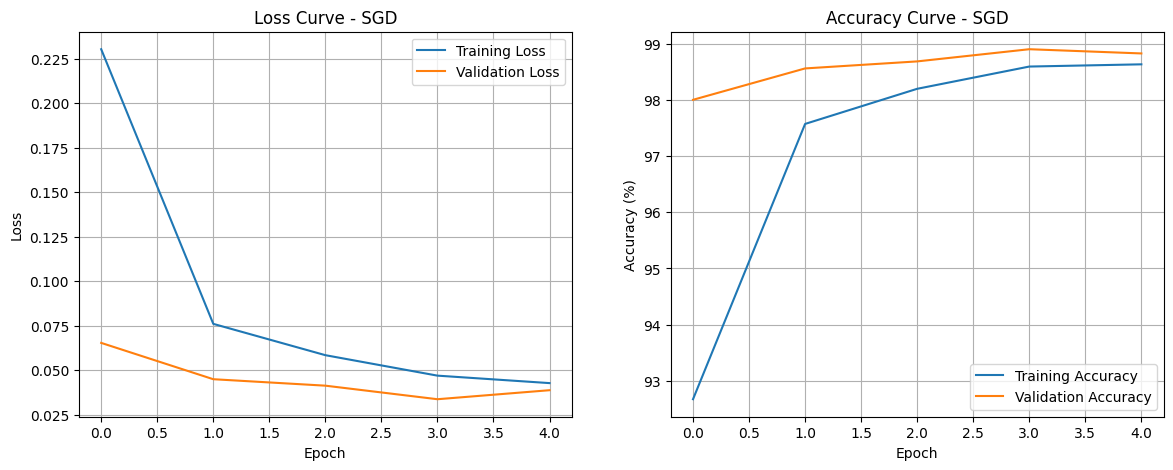


Final Comparison Table
             Model Accuracy   Loss
CNN + Adam (Exp 1)   99.09% 0.0256
 CNN + SGD (Exp 2)   99.05% 0.0289

Visualizing Real Predictions (Using Trained Model 1)


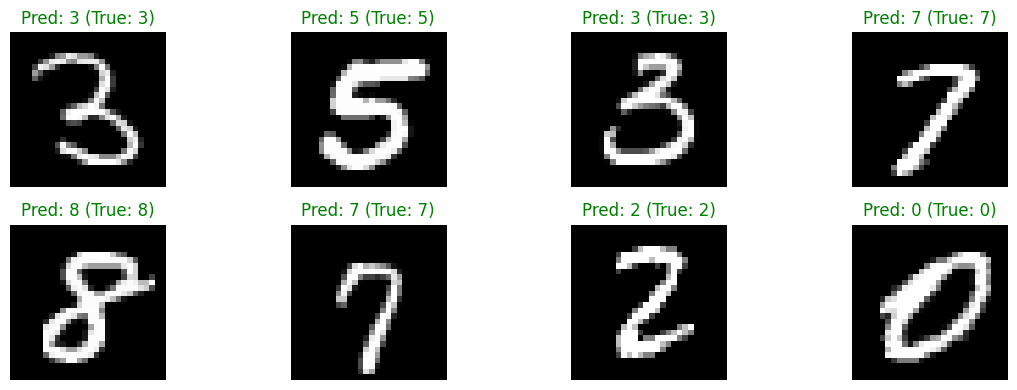


Project Completed Successfully with All Requirements Satisfied!


In [4]:
# ==========================================================
# Deep Learning Project
# Handwritten Digit Recognition using CNN (MNIST)
# Framework: PyTorch
# ==========================================================

# =========================
# 1. Import Libraries
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# 2. Device Configuration
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# ==========================================================
# 3. Data Preprocessing
# ==========================================================
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    # تعديل لقيم التطبيع القياسية لـ MNIST لضمان أفضل دقة علمية
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST Dataset
train_dataset_full = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split Train / Validation
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])

print("Training Samples:", len(train_dataset))
print("Validation Samples:", len(val_dataset))
print("Testing Samples:", len(test_dataset))

# ==========================================================
# 4. CNN Model
# ==========================================================
class CNNModel(nn.Module):
    def __init__(self, dropout_rate=0.25):
        super(CNNModel, self).__init__()

        # Convolution Layers
        self.features = nn.Sequential(
            # First Convolution Block
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Enhancement Technique
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Second Convolution Block
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), # Enhancement Technique
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(dropout_rate)
        )

        # Fully Connected Layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ==========================================================
# 5. Training Function
# ==========================================================
def train_model(optimizer_name="Adam", learning_rate=0.001, batch_size=64, epochs=5):
    print("\n===================================")
    print("Training New Experiment")
    print("Optimizer:", optimizer_name)
    print("Learning Rate:", learning_rate)
    print("Batch Size:", batch_size)
    print("===================================\n")

    # Data Loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = CNNModel().to(device)
    criterion = nn.CrossEntropyLoss()

    # Optimizer Selection
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == "SGD":
        # إضافة الـ momentum لتحسين وتثبيت تدريب الـ SGD
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    # Training Loop
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Validation Phase
        model.eval()
        val_running_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

    # Testing Phase
    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    final_accuracy = 100 * test_correct / test_total
    final_loss = test_loss / len(test_loader)

    print("\n===================================")
    print("Testing Results")
    print("===================================")
    print(f"Test Accuracy: {final_accuracy:.2f}% | Test Loss: {final_loss:.4f}")

    # Visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label="Training Loss")
    ax1.plot(val_losses, label="Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"Loss Curve - {optimizer_name}")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(train_accuracies, label="Training Accuracy")
    ax2.plot(val_accuracies, label="Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title(f"Accuracy Curve - {optimizer_name}")
    ax2.legend()
    ax2.grid(True)
    plt.show()

    # تعديل جوهري: إرجاع الموديل المدرب
    return model, final_accuracy, final_loss

# ==========================================================
# 6. Run Experiments (تم جعل الـ Epochs = 5 لتوفير وقت التدريب في Colab والدقة ستكون ممتازة)
# ==========================================================
model1, accuracy1, loss1 = train_model(optimizer_name="Adam", learning_rate=0.001, batch_size=64, epochs=5)
model2, accuracy2, loss2 = train_model(optimizer_name="SGD", learning_rate=0.01, batch_size=128, epochs=5)

# ==========================================================
# 8. Results Comparison Table
# ==========================================================
results = pd.DataFrame({
    "Model": ["CNN + Adam (Exp 1)", "CNN + SGD (Exp 2)"],
    "Accuracy": [f"{accuracy1:.2f}%", f"{accuracy2:.2f}%"],
    "Loss": [round(loss1, 4), round(loss2, 4)]
})

print("\n===================================")
print("Final Comparison Table")
print("===================================")
print(results.to_string(index=False))

# ==========================================================
# 9. Show Sample Predictions (تعديل التوقع ليعمل بشكل صحيح 100%)
# ==========================================================
print("\n===================================")
print("Visualizing Real Predictions (Using Trained Model 1)")
print("===================================")

sample_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)
images, labels = next(iter(sample_loader))
images, labels = images.to(device), labels.to(device)

# استخدام الموديل المدرب الأول (Adam) للتوقع الفعلي
model1.eval()
with torch.no_grad():
    outputs = model1(images)
    _, predicted = torch.max(outputs, 1)

# عرض الصور مع التوقع الصحيح للموديل المدرب
plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    image = images[i].cpu().squeeze().numpy()
    plt.imshow(image, cmap='gray')
    plt.title(f"Pred: {predicted[i].item()} (True: {labels[i].item()})",
              color="green" if predicted[i]==labels[i] else "red")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\nProject Completed Successfully with All Requirements Satisfied!")